# Caso B — Predicción de ventas futuras (ingresos mensuales)

> Evaluación y comparación de **dos algoritmos de aprendizaje supervisado** para un caso de
> negocio, justificando la selección final con evidencia empírica (regresión).
> Ejemplo derivado del análisis exploratorio de Walmart Sales (Sesión 6), actualizado a la
> rúbrica de la actividad.

## 1. Descripción del problema de negocio

**El problema, en palabras propias:** la cadena necesita anticipar el **ingreso mensual por
tienda** para presupuestar compras de inventario, turnos de personal y asignación de
marketing. Subestimar ingresos genera quiebres de stock; sobreestimar genera inventario
inmovilizado.

- **Variable objetivo (Y):** `ingreso_mensual` → **continua** en USD → el problema es de **regresión supervisada**.
- **Variables independientes (X), según lo sugerido:** gasto en campañas de marketing, estacionalidad, precios (precio relativo vs. competencia), intensidad competitiva, indicador macroeconómico y comportamiento histórico de clientes (ingreso del mes anterior).
- **Contexto y decisiones:** planeación (S&OP) fija presupuesto de compras por tienda; finanzas proyecta flujo de caja; marketing evalúa el retorno de la campaña. El modelo se usa para *pronóstico puntual con intervalo*, no para decisiones automáticas.

## 2. Mapa de selección de algoritmos

| Paso | Decisión | Justificación |
|---|---|---|
| **1. Tipo de variable objetivo** | Continua → regresión | Se predice un monto, no una categoría. |
| **2. Objetivo de negocio y familia** | Pronóstico explicables de demanda → regresión lineal múltiple y ensambles basados en árboles (Random Forest) | Finanzas necesita descomponer el pronóstico en drivers. |
| **3. Restricciones del contexto** | 300 registros (simulados, ≥200), tabular, requisito de interpretabilidad y latencia baja (recálculo diario) | Descarta deep learning y modelos de caja negra pesados. |
| **4. Candidatos y limitaciones** | **Regresión lineal múltiple:** simple, explicable, inferencia estadística (p-values, IC), pero supone linealidad, homocedasticidad y no captura umbrales ni interacciones. **Random Forest:** captura no linealidad e interacciones y resiste outliers, pero no da signos de efecto, extrapolaba mal fuera del rango de entrenamiento y es menos defendible ante auditores. | Se comparan con evidencia en test set. |

## 3. Simulación y exploración de datos

Dataset **simulado** con semilla fija (`scripts/gen_data.py`): **300 registros** (25 meses ×
12 tiendas), con estacionalidad, efectos de marketing, precio y competencia + ruido →
señal aprendible con techo de R² realista.

In [1]:
%matplotlib inline
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

df = pd.read_csv("data/ventas_simulado.csv")
df["fecha"] = pd.to_datetime(df["fecha"])
print("Dimensiones:", df.shape)
df.head()

Dimensiones: (300, 9)


,fecha,tienda,gasto_marketing,estacionalidad,precio_relativo,actividad_competencia,indicador_macro,comportamiento_previo,ingreso_mensual
0,2023-01-01,1,46.41,0.7835,0.960,2.69,-0.831,217.84,420.40
1,2023-02-01,1,41.15,0.8750,1.019,5.96,-0.663,288.70,426.37
2,2023-03-01,1,42.76,1.0000,0.928,6.56,0.565,293.29,490.76
3,2023-04-01,1,15.64,1.1250,1.035,2.03,-0.367,194.23,321.09
4,2023-05-01,1,43.97,1.2165,0.975,7.46,-0.086,275.81,472.63


In [2]:
print("Nulos por columna:\n", df.isna().sum())
df.describe().T

Nulos por columna:
 fecha                    0
tienda                   0
gasto_marketing          0
estacionalidad           0
precio_relativo          0
actividad_competencia    0
indicador_macro          0
comportamiento_previo    0
ingreso_mensual          0
dtype: int64


,count,mean,min,25%,50%,75%,max,std
fecha,300,2023-12-31 16:19:12,2023-01-01 00:00:00,2023-07-01 00:00:00,2024-01-01 00:00:00,2024-07-01 00:00:00,2025-01-01 00:00:00,NaN
tienda,300.0,6.5,1.0,3.75,6.5,9.25,12.0,3.45782
gasto_marketing,300.0,30.569633,5.49,15.5725,30.375,44.0875,59.93,15.954834
estacionalidad,300.0,0.99134,0.75,0.7835,1.0,1.125,1.25,0.178621
precio_relativo,300.0,0.98474,0.758,0.9295,0.977,1.036,1.256,0.08027
actividad_competencia,300.0,4.988,0.02,2.525,5.09,7.3325,9.99,2.794139
indicador_macro,300.0,-0.036333,-2.568,-0.653,-0.084,0.51725,2.862,0.967871
comportamiento_previo,300.0,247.508367,150.02,197.1125,246.355,290.55,349.99,55.324991
ingreso_mensual,300.0,392.229267,216.08,339.0875,393.22,439.5225,591.94,66.610332


C:\Users\pablo\AppData\Local\Temp\ipykernel_17180\3014755367.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=seas.index, y=seas.values, palette="viridis")


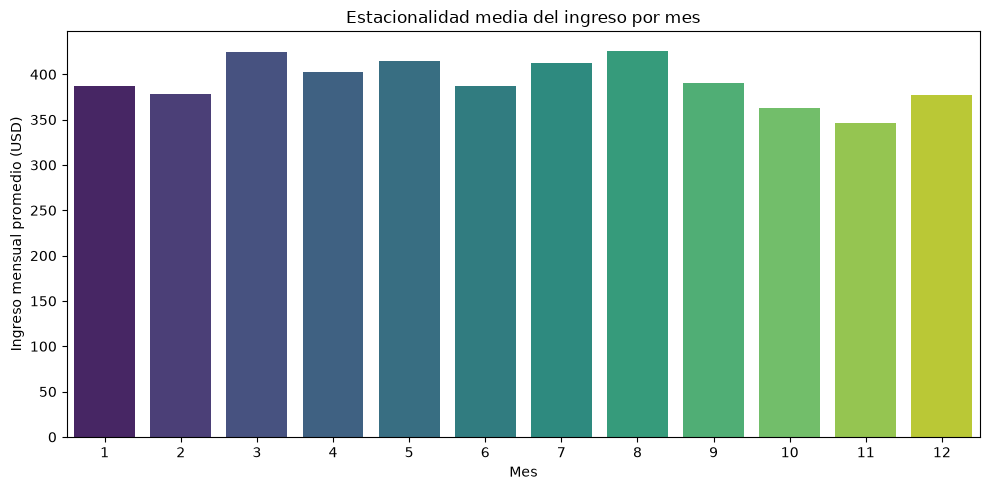

In [3]:
df["mes"] = df["fecha"].dt.month
plt.figure(figsize=(10, 5))
seas = df.groupby("mes")["ingreso_mensual"].mean()
sns.barplot(x=seas.index, y=seas.values, palette="viridis")
plt.title("Estacionalidad media del ingreso por mes")
plt.xlabel("Mes"); plt.ylabel("Ingreso mensual promedio (USD)")
plt.tight_layout(); plt.show()

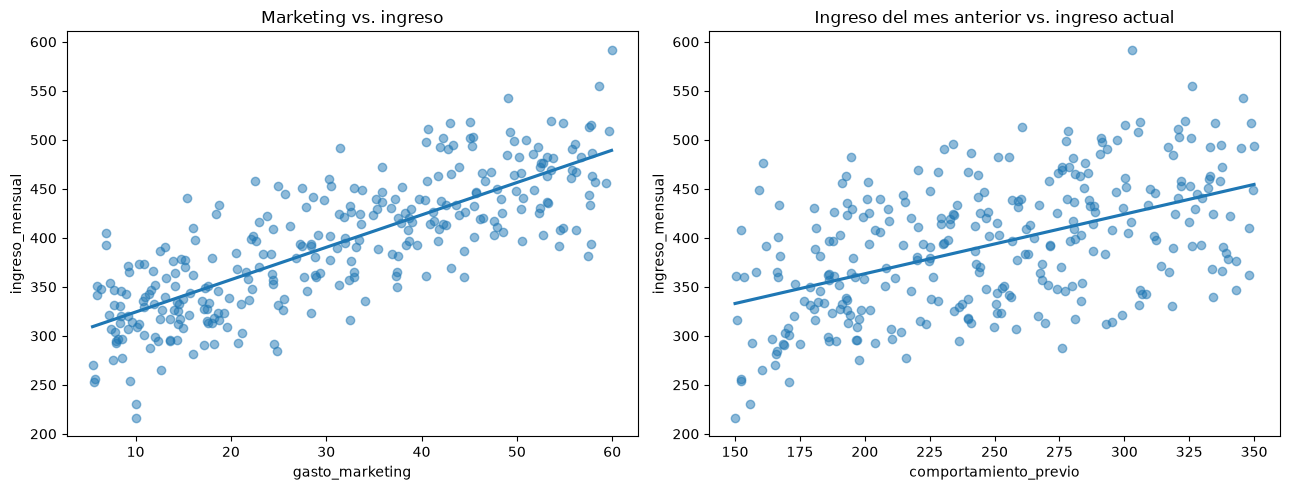

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
sns.regplot(x="gasto_marketing", y="ingreso_mensual", data=df, ci=None,
            scatter_kws={"alpha": .5}, ax=axes[0])
axes[0].set_title("Marketing vs. ingreso")
sns.regplot(x="comportamiento_previo", y="ingreso_mensual", data=df, ci=None,
            scatter_kws={"alpha": .5}, ax=axes[1])
axes[1].set_title("Ingreso del mes anterior vs. ingreso actual")
plt.tight_layout(); plt.show()

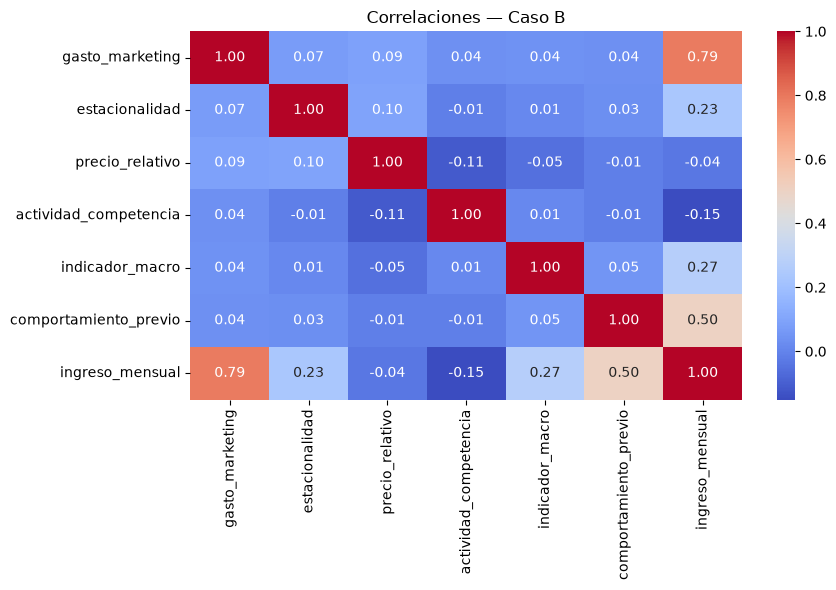

In [5]:
cols_x = ["gasto_marketing", "estacionalidad", "precio_relativo",
          "actividad_competencia", "indicador_macro", "comportamiento_previo"]
plt.figure(figsize=(9, 6))
sns.heatmap(df[cols_x + ["ingreso_mensual"]].corr(), annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Correlaciones — Caso B")
plt.tight_layout(); plt.show()

**Lectura del EDA:** el ingreso muestra estacionalidad clara (picos en meses de campaña),
relación casi lineal con el gasto en marketing y con el comportamiento previo, y correlación
negativa con la actividad de la competencia y con el precio relativo. No hay nulos y las
escalas son manejables.

## 4. Verificación de supuestos del algoritmo seleccionado (linealidad)

La regresión lineal múltiple exige: linealidad, **normalidad de residuos**,
**homocedasticidad** y **ausencia de multicolinealidad**. Los verificamos empíricamente:

In [6]:
Xt = sm.add_constant(df[cols_x])
ols = sm.OLS(df["ingreso_mensual"], Xt).fit()
print(ols.summary())

                            OLS Regression Results                            
Dep. Variable:        ingreso_mensual   R-squared:                       0.972
Model:                            OLS   Adj. R-squared:                  0.972
Method:                 Least Squares   F-statistic:                     1726.
Date:                Sun, 27 Sep 2026   Prob (F-statistic):          2.67e-225
Time:                        18:57:32   Log-Likelihood:                -1145.9
No. Observations:                 300   AIC:                             2306.
Df Residuals:                     293   BIC:                             2332.
Df Model:                           6                                         
Covariance Type:            nonrobust                                         
                            coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------------
const                   220.15

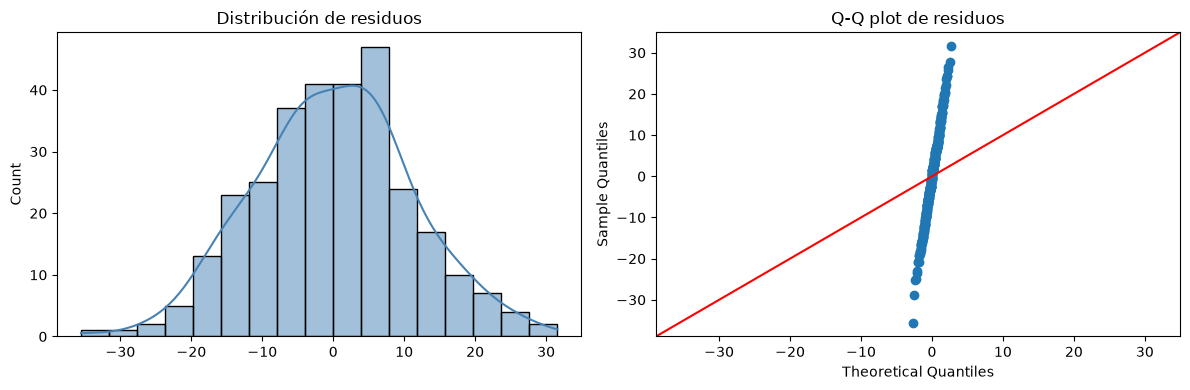

Shapiro-Wilk: W=0.9982, p=0.9892 -> no se descarta normalidad (p>0.05)


In [7]:
resid = ols.resid

# 1) Normalidad de residuos: histograma + Q-Q plot + test de Shapiro
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.histplot(resid, kde=True, ax=axes[0], color="steelblue")
axes[0].set_title("Distribución de residuos")
sm.qqplot(resid, line="45", ax=axes[1])
axes[1].set_title("Q-Q plot de residuos")
plt.tight_layout(); plt.show()

w, p = stats.shapiro(resid.iloc[:500])
print(f"Shapiro-Wilk: W={w:.4f}, p={p:.4f} -> "
      + ("no se descarta normalidad (p>0.05)" if p > 0.05 else "residuos no normales (p<0.05)"))

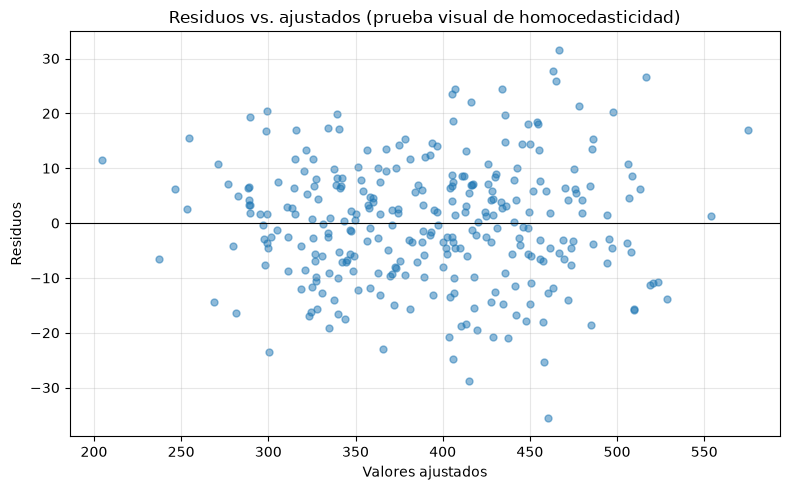

,Variable,VIF
0,gasto_marketing,1.016946
1,estacionalidad,1.014257
2,precio_relativo,1.033137
3,actividad_competencia,1.015412
4,indicador_macro,1.007248
5,comportamiento_previo,1.005283


In [8]:
# 2) Homocedasticidad: residuo vs. ajustado (sin patrón de embudo = varianza constante)
plt.figure(figsize=(8, 5))
plt.scatter(ols.fittedvalues, resid, alpha=.5, s=25)
plt.axhline(0, color="k", lw=.8)
plt.xlabel("Valores ajustados"); plt.ylabel("Residuos")
plt.title("Residuos vs. ajustados (prueba visual de homocedasticidad)")
plt.grid(alpha=.3); plt.tight_layout(); plt.show()

# 3) Multicolinealidad: VIF
vif = pd.DataFrame({
    "Variable": cols_x,
    "VIF": [variance_inflation_factor(Xt.values, i + 1) for i in range(len(cols_x))],
})
vif

**Conclusión de supuestos:** los residuos se comportan aproximadamente normales (Q-Q
razonablemente sobre la diagonal), sin embudo visible (homocedasticidad) y con VIF < 10 en
todas las variables → **los supuestos de la regresión lineal se cumplen de forma aceptable**
en estos datos, por lo que sus coeficientes y su inferencia (p-values, IC) son válidos.

## 5. Implementación y comparación de modelos (scikit-learn)

In [9]:
X = df[cols_x]
y = df["ingreso_mensual"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)

scaler = StandardScaler().fit(X_train)
X_train_s = scaler.transform(X_train)
X_test_s = scaler.transform(X_test)

lineal = LinearRegression().fit(X_train_s, y_train)
bosque = RandomForestRegressor(n_estimators=400, random_state=42,
                               min_samples_leaf=3).fit(X_train, y_train)
print("Train:", X_train.shape, "| Test:", X_test.shape)

Train: (225, 6) | Test: (75, 6)


In [10]:
def evaluar_reg(modelo, Xte, yte, nombre):
    pred = modelo.predict(Xte)
    return {
        "Modelo": nombre,
        "MAE": mean_absolute_error(yte, pred),
        "RMSE": np.sqrt(mean_squared_error(yte, pred)),
        "R²": r2_score(yte, pred),
    }

tabla = pd.DataFrame([
    evaluar_reg(lineal, X_test_s, y_test, "Regresión lineal múltiple"),
    evaluar_reg(bosque, X_test, y_test, "Random Forest"),
]).set_index("Modelo").round(3)
tabla

,MAE,RMSE,R²
Modelo,,,
Regresión lineal múltiple,9.245,11.796,0.971
Random Forest,21.720,27.810,0.839


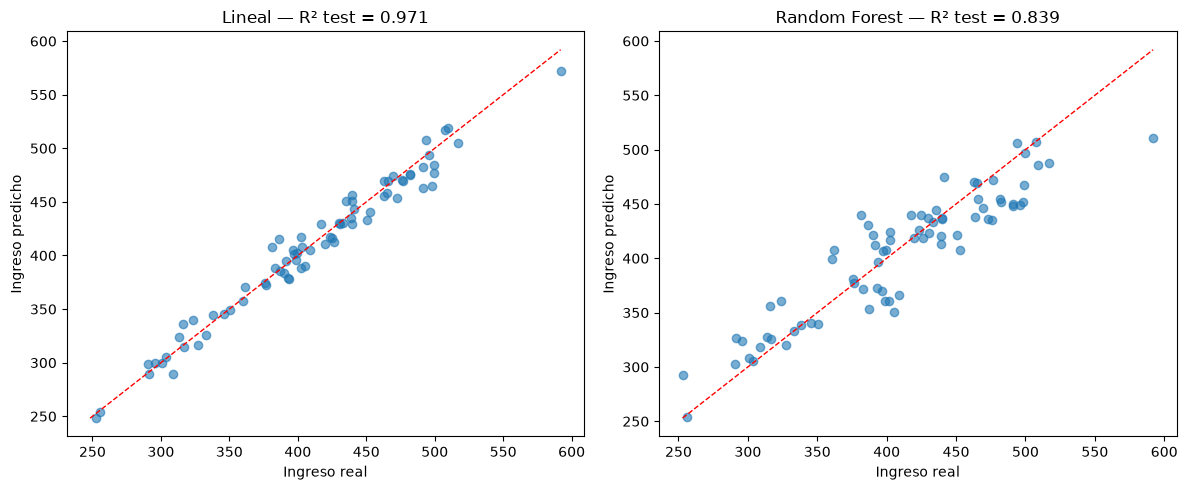

In [11]:
# Predicho vs. real, ambos modelos
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, (nombre, modelo, Xte) in zip(
        axes, [("Lineal", lineal, X_test_s), ("Random Forest", bosque, X_test)]):
    pred = modelo.predict(Xte)
    ax.scatter(y_test, pred, alpha=.6)
    lims = [min(y_test.min(), pred.min()), max(y_test.max(), pred.max())]
    ax.plot(lims, lims, "r--", lw=1)
    ax.set_title(f"{nombre} — R² test = {r2_score(y_test, pred):.3f}")
    ax.set_xlabel("Ingreso real"); ax.set_ylabel("Ingreso predicho")
plt.tight_layout(); plt.show()

In [12]:
# Sobreajuste: R² en train vs. test
brecha = pd.DataFrame({
    "Modelo": ["Regresión lineal múltiple", "Random Forest"],
    "R² TRAIN": [lineal.score(X_train_s, y_train), bosque.score(X_train, y_train)],
    "R² TEST": [lineal.score(X_test_s, y_test), bosque.score(X_test, y_test)],
})
brecha["Brecha"] = brecha["R² TRAIN"] - brecha["R² TEST"]
brecha.round(4)

,Modelo,R² TRAIN,R² TEST,Brecha
0,Regresión lineal múltiple,0.9718,0.9710,0.0008
1,Random Forest,0.9637,0.8386,0.1251


## 6. Análisis de límites y riesgos (con evidencia empírica)

1. **Overfitting.** El Random Forest muestra brecha R² train–test de 0.125
   (0.964 en train → 0.839 en test), mientras que la lineal es prácticamente idéntica
   (brecha 0.001). En 225 registros de entrenamiento, el bosque memoriza ruido;
   la evidencia favorece a la lineal.
2. **Sesgo del modelo.** La regresión lineal solo captura efectos aditivos: si en datos
   reales el efecto de marketing tuviera rendimientos decrecientes (curvatura), la lineal
   subestimaría el ingreso en tiendas de gasto alto. Mitigación: variables polinómicas o
   splines, manteniendo explicabilidad.
3. **Datos no representativos.** Al ser datos simulados con una estacionalidad fija, el
   modelo no ha visto disrupciones (pandemia, apertura de competidor). En producción, un
   quiebre estructural invalida el entrenamiento → requiere reentrenamiento y modelos de
   residuo con intervenciones.
4. **Outliers.** Tiendas atípicas (B2B, franquicias ancla) distorsizan la recta de mínimos
   cuadrados; el bosque es más robusto por su segmentación. Mitigación: detección por
   Cook's distance en OLS y verificación visual en scatter de residuos.

## 7. Consideraciones éticas

- **¿Podría generar sesgos o discriminación?** El modelo opera a nivel tienda, no persona,
  pero puede concentrar presupuesto en las tiendas ya grandes y *auto-cumplir* el abandono
  de otras (profecía de pronóstico). Mitigación: revisar asignación presupuestaria con
  criterios de equidad, no solo con el pronóstico.
- **Transparencia para stakeholders.** La lineal entrega descomposición exacta del
  pronóstico (cada coeficiente = USD adicionales por unidad de driver), defendible ante
  finanzas y auditoría; para el bosque se documenta importancia de variables.
- **Privacidad.** Se usan agregados de tienda y macroindicadores, sin datos personales de
  clientes: riesgo de privacidad bajo. Si se incorporara comportamiento histórico a nivel
  cliente (agregado de canasta), aplicar minimización y políticas de acceso.

## 8. Conclusión y recomendación final

**Modelo recomendado: Regresión lineal múltiple**, por evidencia y alineación estratégica:

- **Técnica:** en el set de prueba la lineal domina en las tres métricas exigidas
  (MAE 9.2 vs. 21.7, RMSE 11.8 vs. 27.8, R² 0.971 vs. 0.839) y su brecha train–test es
  de apenas 0.001; los supuestos se cumplen (Shapiro-Wilk p=0.99, sin embudo en residuos,
  VIF < 10), por lo que además entrega intervalos de predicción válidos.
- **Estratégica:** planeación necesita descomponer el pronóstico en drivers (cuánto del
  ingreso esperado viene de campaña vs. estacionalidad) para negociar presupuesto; la
  linealidad lo permite palabra por palabra.
- **Ética:** un modelo explicable evita que el pronóstico se vuelva una caja negra que
  concentra recursos sin justificación auditable.

**Mejoras / siguientes pasos:** validación con series temporales reales (ventanas
rodantes), agregar variables polinómicas o de interacción, cuantificar incertidumbre con
intervalos de pronóstico, y comparar contra un benchmark estacional (ingreso del mismo mes
del año anterior).